# Dirichlet Distribution Demo

The Dirichlet distribution is a multivariate probability distribution that models the probabilities of outcomes across multiple categories.

## Setup

In [1]:
from symbulate import *

## Draw a value from a Dirichlet distribution

Each draw is a vector of proportions that sums to 1.

In [2]:
Dirichlet(alpha=[2, 3, 5]).draw()

(0.24777781944161173, 0.274900583526039, 0.4773215970323492)

Confirm the shape of the results and that every draw sums to 1.

In [3]:
Dirichlet(alpha=[2, 3, 5]).sim(1000)

0,"(0.25200969235100357, 0.41965022279255465, 0.32834008485644167)"
1,"(0.18402165563580444, 0.2215525044374174, 0.5944258399267782)"
2,"(0.062400674493216575, 0.5245840296642297, 0.4130152958425537)"
3,"(0.1748812154428562, 0.31913807886559187, 0.5059807056915521)"
4,"(0.2207168224600805, 0.4156630245479523, 0.3636201529919672)"
5,"(0.17884603870766677, 0.2063783889085168, 0.6147755723838164)"
6,"(0.11581219342767707, 0.27545270158350127, 0.6087351049888217)"
7,"(0.15327847775149955, 0.4406390034423128, 0.4060825188061877)"
8,"(0.04977499693038069, 0.5403341893216419, 0.4098908137479774)"
...,...
999,"(0.4814473302919729, 0.38421730359118217, 0.13433536611684477)"


## Theoretical mean, variance, and standard deviation

The mean is `alpha / sum(alpha)`. `var()` and `sd()` give the per-category variance and standard deviation.

In [4]:
Dirichlet(alpha=[2, 3, 5]).mean(), Dirichlet(alpha=[2, 3, 5]).var(), Dirichlet(alpha=[2, 3, 5]).sd()

((0.2, 0.3, 0.5),
 (0.014545454545454545, 0.01909090909090909, 0.022727272727272728),
 (0.12060453783110545, 0.13816985594155148, 0.15075567228888181))

## Covariance matrix

`cov()` returns the full covariance matrix. Its diagonal holds the same variances shown above.

In [5]:
Dirichlet(alpha=[2, 3, 5]).cov()

array([[ 0.01454545, -0.00545455, -0.00909091],
       [-0.00545455,  0.01909091, -0.01363636],
       [-0.00909091, -0.01363636,  0.02272727]])

## Correlation matrix

`corr()` rescales the covariance into correlations between -1 and 1.

In [6]:
Dirichlet(alpha=[2, 3, 5]).corr()

array([[ 1.        , -0.32732684, -0.5       ],
       [-0.32732684,  1.        , -0.65465367],
       [-0.5       , -0.65465367,  1.        ]])

Evaluate the probability density at a point on the simplex (the point must sum to 1).

In [7]:
Dirichlet(alpha=[2, 3, 5]).pdf([0.4, 0.2, 0.4])

np.float64(3.096576)

## Plot the marginal of each proportion

Each proportion is marginally a Beta distribution, so the plot overlays one Beta curve per category.

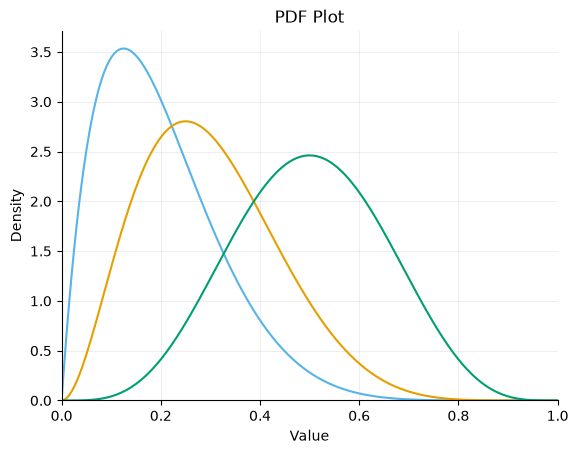

In [8]:
Dirichlet(alpha=[2, 3, 5]).plot()

## Relationship: each proportion is marginally Beta

Component `i` of a `Dirichlet(alpha)` is `Beta(alpha_i, sum(alpha) - alpha_i)`. Here `alpha = [2, 3, 5]` sums to 10, so the first proportion is `Beta(2, 8)`.

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


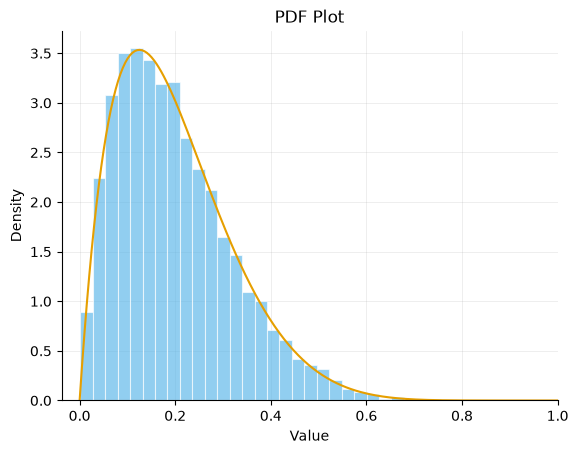

In [9]:
p1, p2, p3 = RV(Dirichlet(alpha=[2, 3, 5]))
p1.sim(10000).plot()
Beta(2, 8).plot()

## Relationship: two categories is a Beta

With only two categories the Dirichlet is just a Beta: the first proportion of `Dirichlet([a, b])` is `Beta(a, b)`.

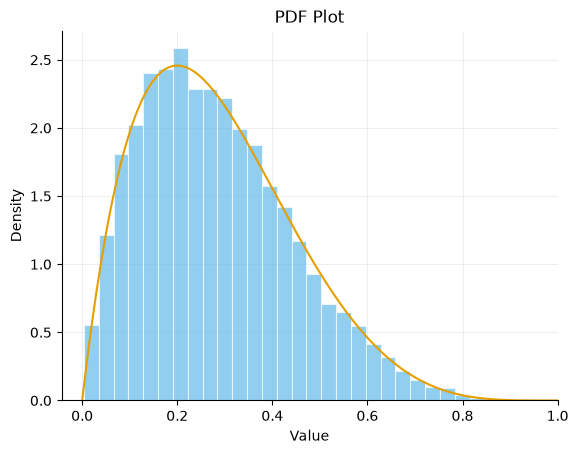

In [10]:
q1, q2 = RV(Dirichlet(alpha=[2, 5]))
q1.sim(10000).plot()
Beta(2, 5).plot()